In [1]:
import os
import re
import pandas as pd
import plotnine as pln
from statsmodels.formula.api import ols

In [2]:
def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation)
    if parts:
        wt, site, mut = parts.groups()
        return [wt, int(site), mut]
    else:
        return [None, None, None]


# Variance of ...

In [3]:
res_dict = {'source':[], 'Dataset':[], 'var':[]}

for source in ['cellular', 'viral']:
    dir_path = f'../data/{source}/metadata/'
    for file in os.listdir(dir_path):
        if file not in ['PABP_YEAST_Fields2013_doubles.csv', 'parEparD_Laub2015_all.csv', 'AAV2_CAPSD_Sinai.csv', 'PESV_POLG_Tsuboyama.csv', 'BP434_RPC1_Tsuboyama.csv']:
            data = pd.read_csv(f'../data/{source}/metadata/{file}')
            data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
            
            # equation
            total_std = data['target'].std()
            grouped_data = data.groupby(['site'], as_index=False, observed=True)['target'].mean()
            sd_sites = grouped_data['target'].std()
            var = sd_sites / total_std


            res_dict['source'].append(source)
            res_dict['Dataset'].append(file.replace('.csv', ''))
            res_dict['var'].append(var)

res_var = pd.DataFrame.from_dict(res_dict)
res_var['source'] = pd.Categorical(res_var['source'], categories=['viral', 'cellular'])
res_var

,source,Dataset,var
0,cellular,TIM_THETH,0.707607
1,cellular,TIM_THEMA,0.667472
2,cellular,MK01_HUMAN_Johannessen,0.501967
3,cellular,IF1_ECOLI,0.716184
4,cellular,TIM_SULSO,0.679531
...,...,...,...
69,viral,CVB3_2A_Alvarez,0.776574
70,viral,CVB3_3A_Alvarez,0.648906
71,viral,SARS2_PLPRO_activity_Wu,0.817721
72,viral,SARS2_BA1_SPIKE_Dadonaite,0.682066


# plots

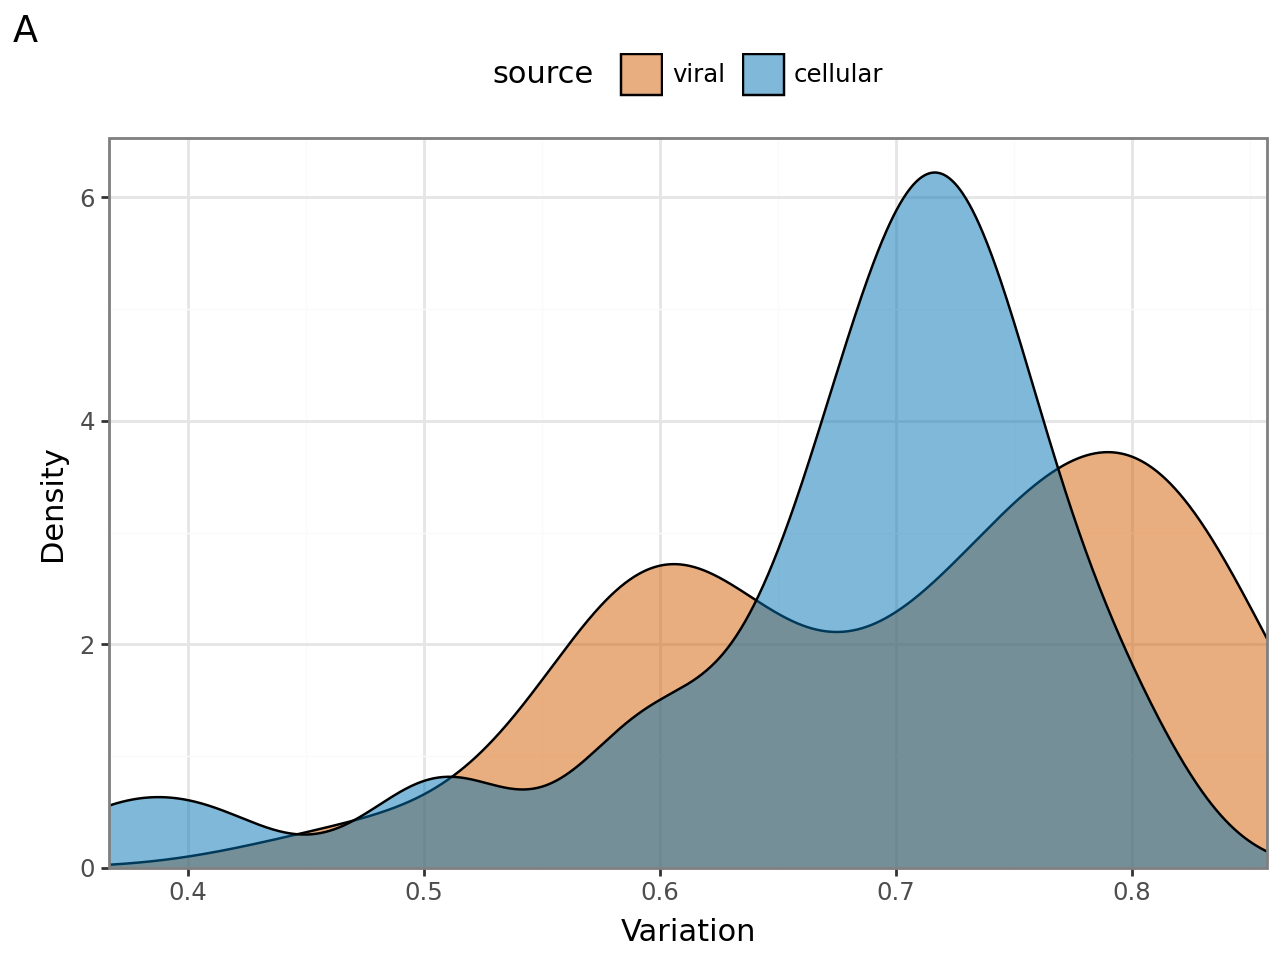

In [4]:
(
    pln.ggplot(res_var, pln.aes(x='var', fill='source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Variation',
        y='Density',
        tag='A')
    + pln.theme(
        legend_position='top')
    )

In [5]:
var_dict = {}
for idx, col in res_var.iterrows():
    var_dict[col['Dataset']] = col['var']


# Results

In [52]:
lassocv = pd.read_csv('../experiments/res_lassoCV_esm2_650m.csv', index_col=0)
lassocv['Source'] = pd.Categorical(lassocv['Source'], categories=['viral', 'cellular'])
#lassocv['variation'] = lassocv['Dataset'].map(var_dict)


p = ["Pooled Split"]
s = ["Site Split"]
a = ["Pooled Split", "Site Split"]

res = lassocv.query('Split in @p')
res

,Model,Source,Split,Dataset,R2_score_test,cv,variance,coverage,prot_length,fractionSD,fractionSD_ranked
0,ESM-2 650M,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.477524,0.895529,0.684369,0.949133,346,0.504399,0.489736
1,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.451530,0.626518,0.596003,0.948633,439,0.660592,0.751708
2,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.245162,0.542289,0.513957,0.918793,439,0.749431,0.890661
3,ESM-2 650M,cellular,Pooled Split,BG_STRSQ_hmmerbit,0.412022,0.837254,0.600783,0.349301,501,0.526946,0.728543
4,ESM-2 650M,cellular,Pooled Split,BLAT_ECOLX_Ostermeier2014,0.653254,0.551118,0.745130,0.955944,286,0.412587,0.391608
...,...,...,...,...,...,...,...,...,...,...,...
102,ESM-2 650M,viral,Pooled Split,SARS2_PLPRO_activity_Wu,0.470377,0.341990,0.817721,0.844146,316,0.295238,0.282540
103,ESM-2 650M,viral,Pooled Split,SARS2_PRD0038_RBD_Starr,0.476183,0.878247,0.806632,0.999500,200,0.300000,0.495000
104,ESM-2 650M,viral,Pooled Split,SARS2_RBD_binding_Starr,0.524776,0.605886,0.828026,0.149332,1273,0.263682,0.164179
105,ESM-2 650M,viral,Pooled Split,SARS2_RBD_expression_Starr,0.571781,0.455119,0.857385,0.149175,1273,0.194030,0.169154


In [51]:
res.query('variance < 0.7')['Dataset'].unique()

array(['AMIE_PSEAE_Whitehead', 'B3VI55_LIPSTSTABLE',
       'B3VI55_LIPST_Whitehead2015', 'BG_STRSQ_hmmerbit',
       'BRCA1_HUMAN_BRCT', 'CALM1_HUMAN_Roth2017',
       'MK01_HUMAN_Johannessen', 'RL401_YEAST_Fraser2016',
       'SUMO1_HUMAN_Roth2017', 'TIM_SULSO', 'TIM_THEMA',
       'TPK1_HUMAN_Roth2017', 'TPMT_HUMAN_Fowler2018',
       'UBC9_HUMAN_Roth2017', 'UBE4B_MOUSE_Klevit2013_singles',
       'CVB3_2B_Alvarez', 'CVB3_2C_Alvarez', 'CVB3_3A_Alvarez',
       'CVB3_3B_Alvarez', 'CVB3_3C_Alvarez', 'CVB3_3D_Alvarez',
       'CVB3_VP1_Alvarez', 'CVB3_VP3_Alvarez', 'EV_CAPSD_Bakhache',
       'EV_REP_Bakhache', 'HIV1_HV1B9_ENV_DuenasDecamp', 'IAV_H1_HA_Wu',
       'IAV_H1_NP_Doud', 'IAV_RDRP_Li', 'LASSA_GP_Carr',
       'RmYN02_RBD_Starr', 'SARS2_BA1_SPIKE_Dadonaite',
       'SARS2_DELTA_SPIKE_Dadonaite'], dtype=object)

In [53]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

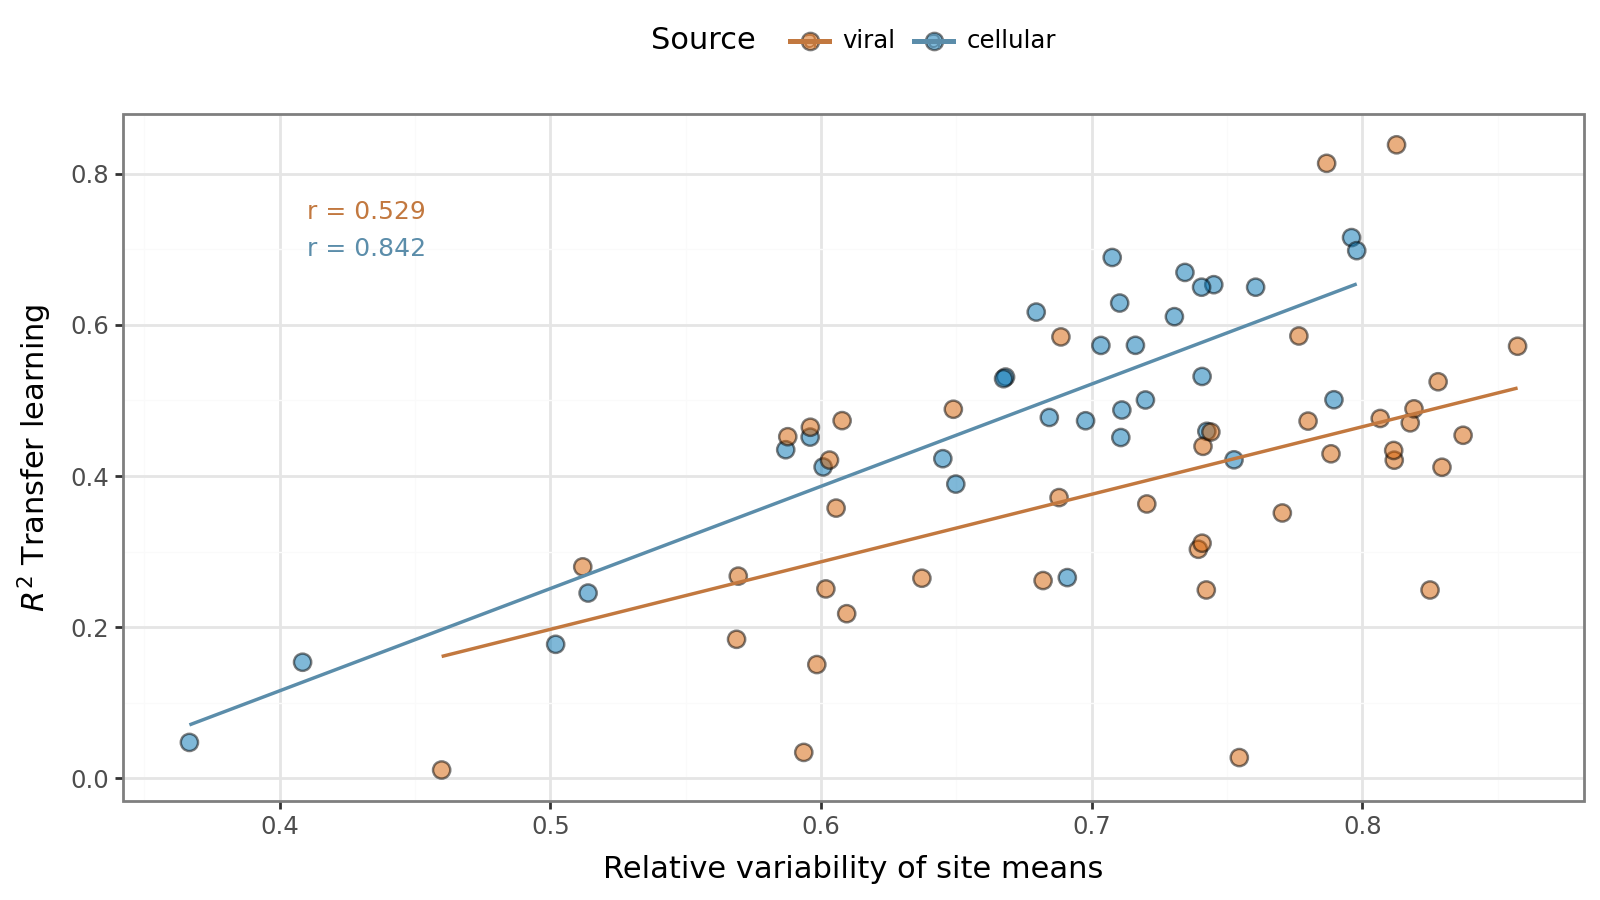

In [ ]:
res = lassocv.query('Split in @p')

target = 'variance'
ann_df = annotation_df(res, target,  y=0.7)
ann_df = ann_df.query('Split == "Pooled Split"')

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Relative variability of site means'),
        tag='B'
    )

# Faceted figures

In [64]:
res = lassocv.query('Split in @a')

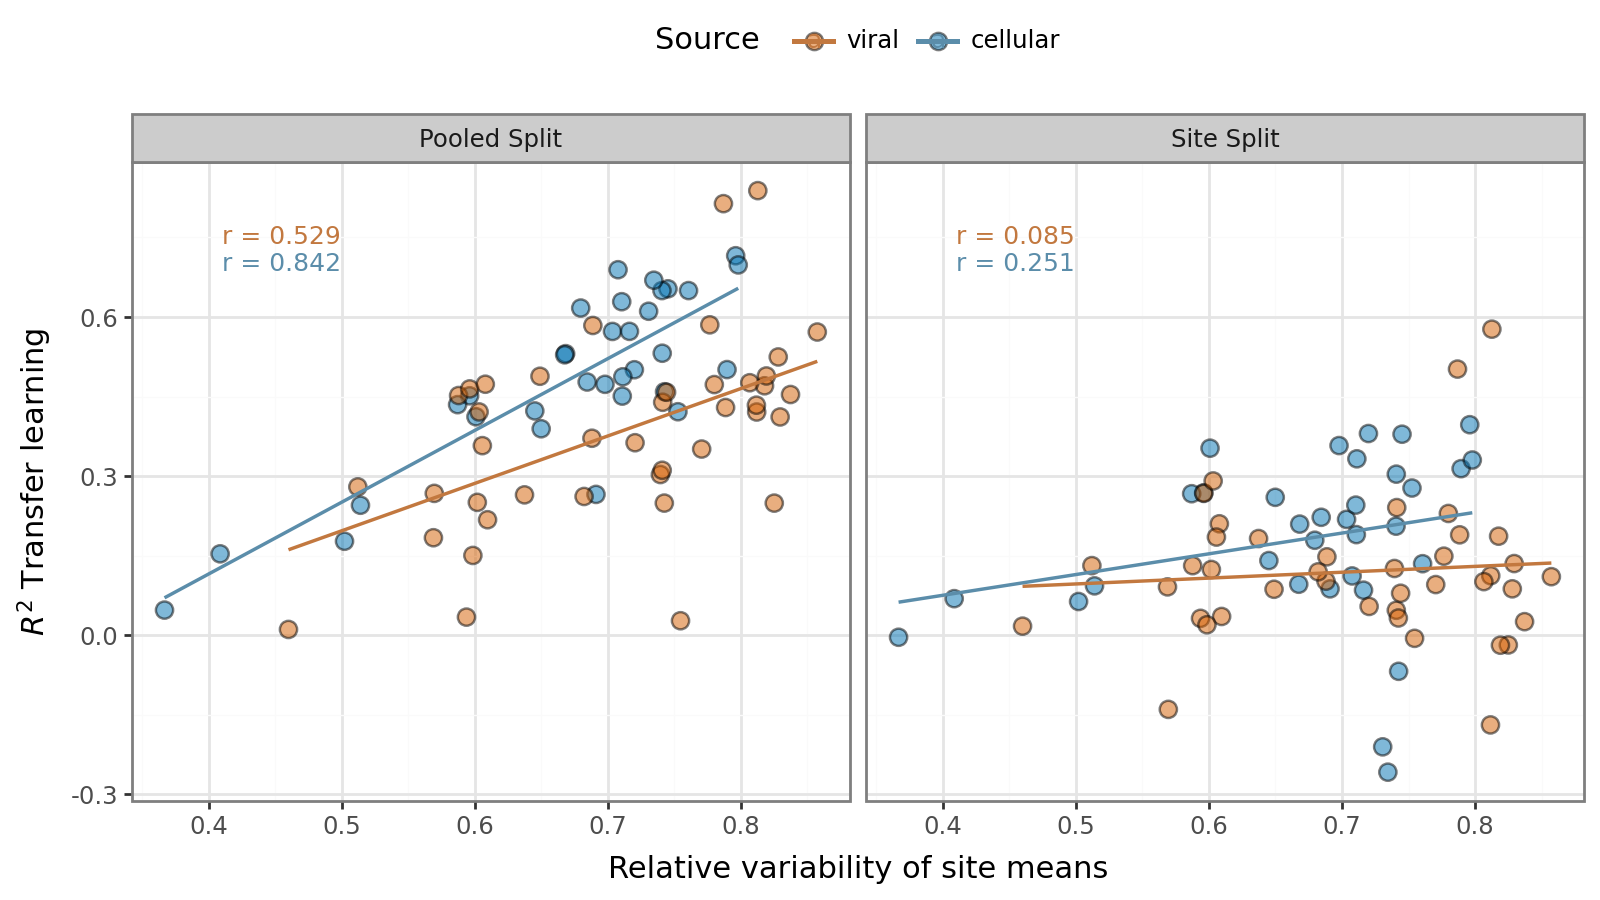

In [65]:
target = 'variance'
ann_df = annotation_df(res, target,  y=0.7)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Relative variability of site means')
    )

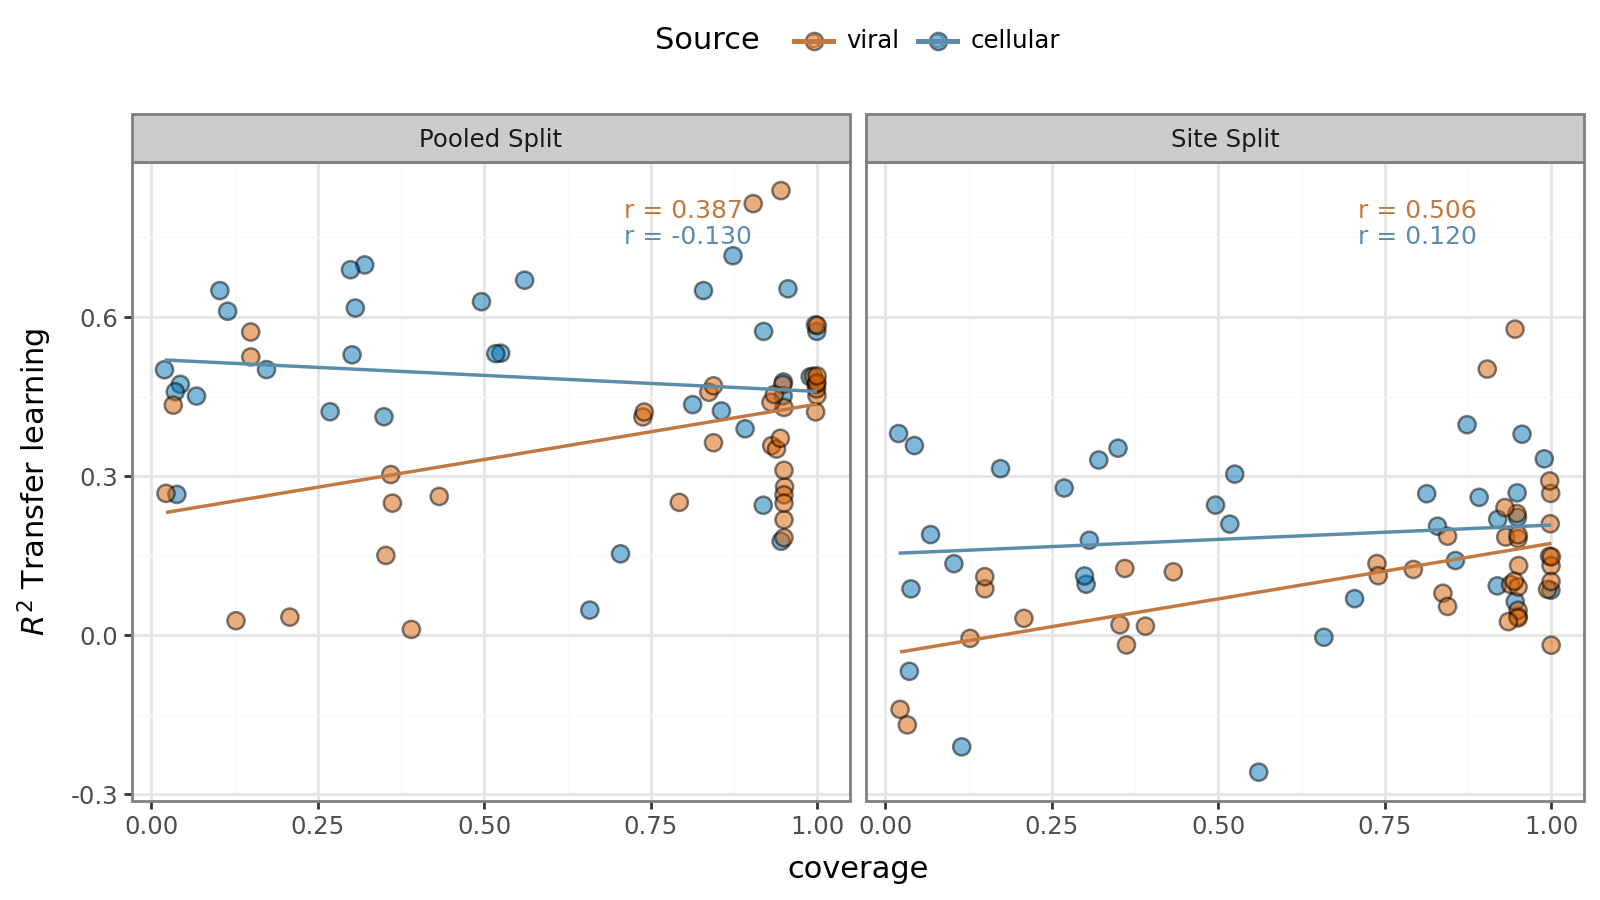

In [66]:
target = 'coverage'
ann_df = annotation_df(res, target, x=0.71, y=0.75)

(
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})

    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(y= '$R^2$ Transfer learning')
    )

In [11]:
model = ols('R2_score_test ~Split+Source+coverage+variance', data=res).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     57.12
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           1.02e-28
Time:                        13:22:15   Log-Likelihood:                 87.910
No. Observations:                 148   AIC:                            -165.8
Df Residuals:                     143   BIC:                            -150.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.2507    

# above cutoff

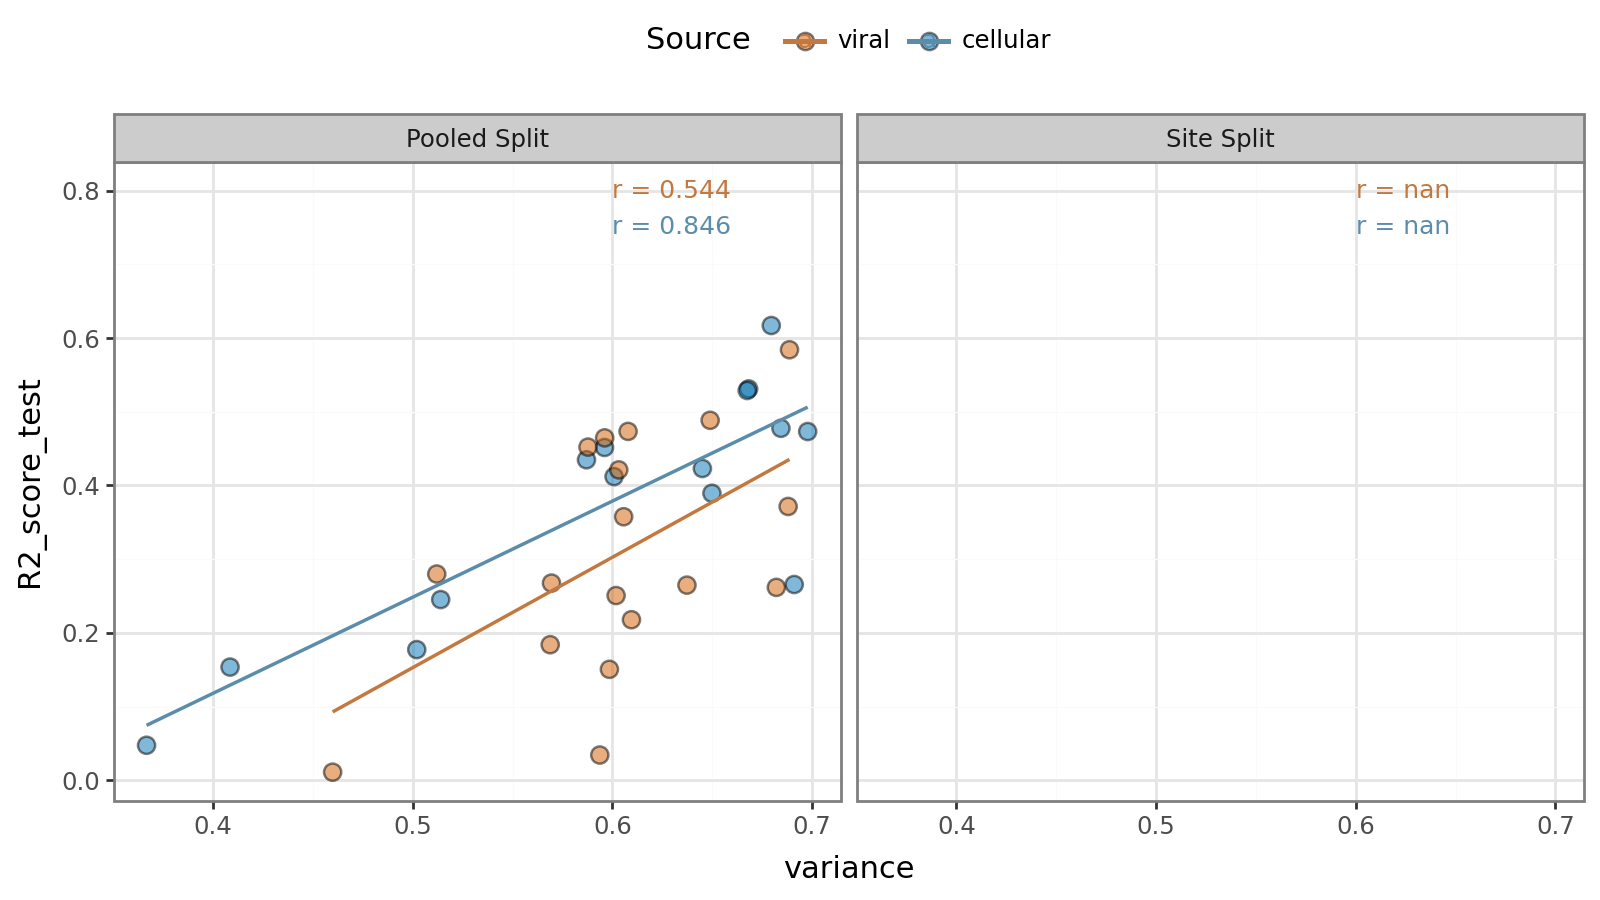

In [61]:
target = 'variance'
res_filteres = res.query('variance < 0.7')
ann_df = annotation_df(res_filteres, target, x=0.6, y=0.75)

(
    pln.ggplot(res_filteres, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})

    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    )

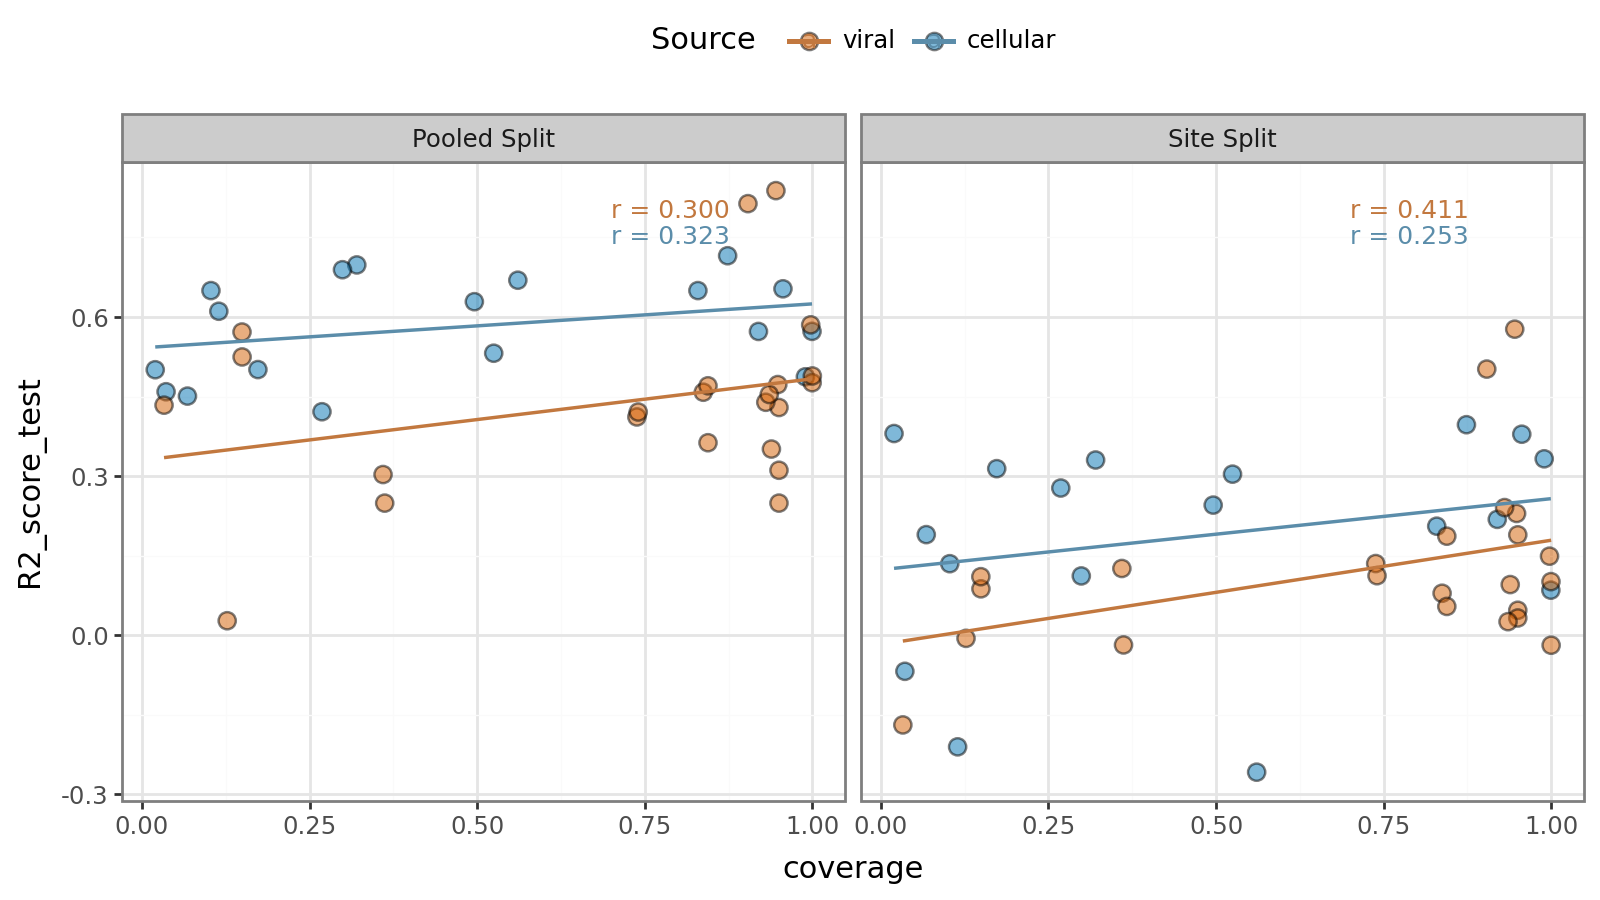

In [69]:
target = 'coverage'
res_filteres = res.query('variance > 0.7')
ann_df = annotation_df(res_filteres, target, x=0.7, y=0.75)

(
    pln.ggplot(res_filteres, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})

    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    )

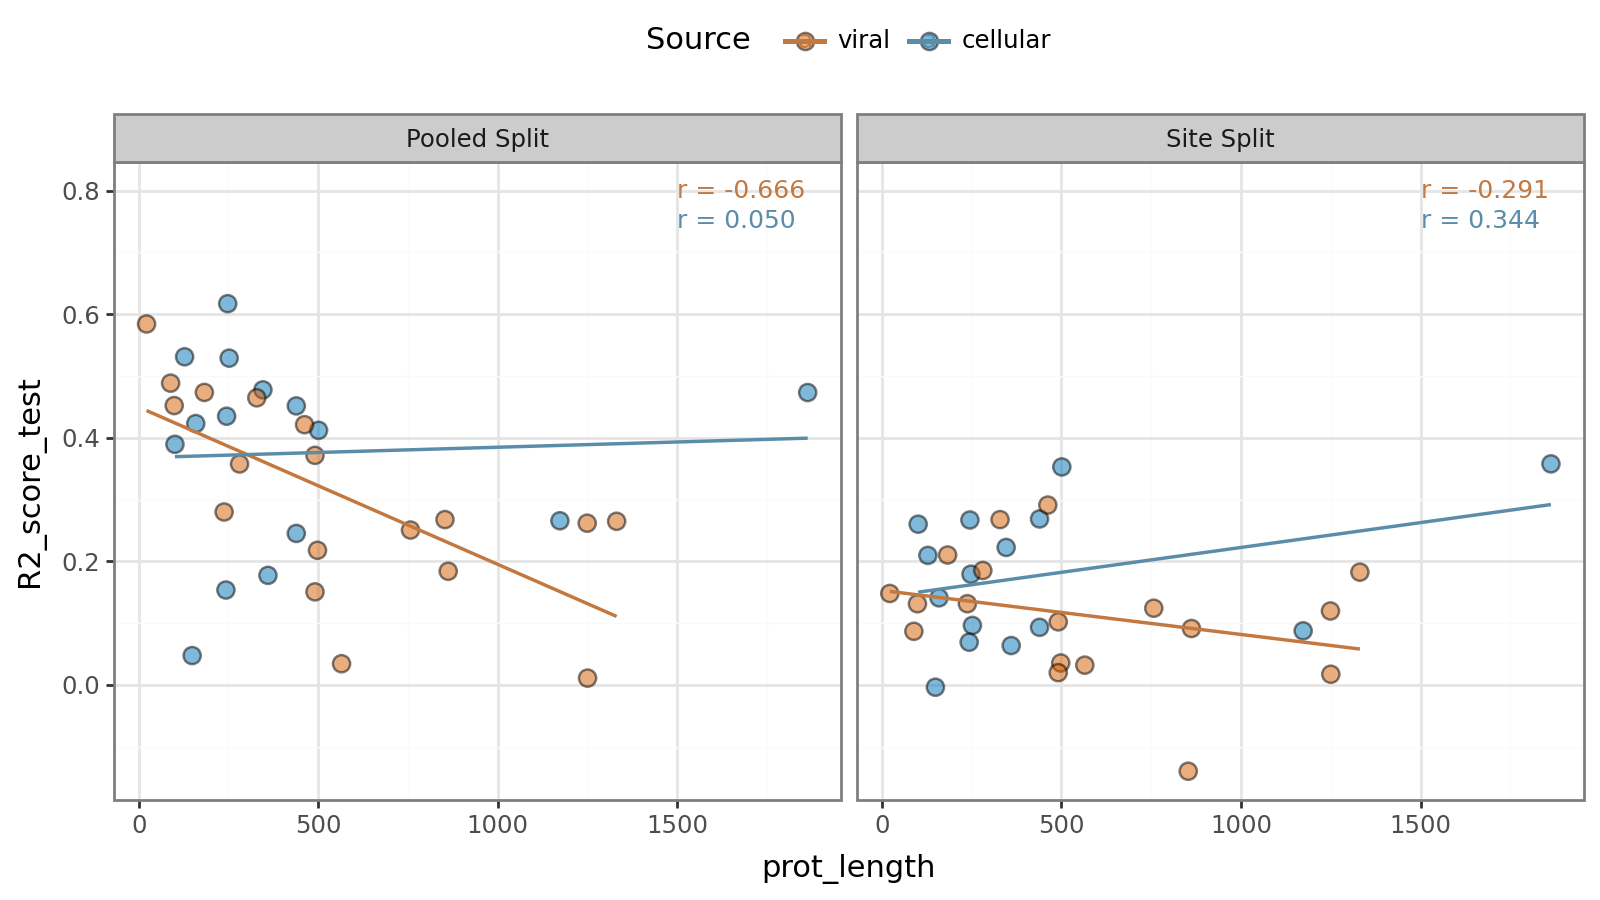

In [68]:
target = 'prot_length'
res_filteres = res.query('variance < 0.7')
ann_df = annotation_df(res_filteres, target, x=1500, y=0.75)

(
    pln.ggplot(res_filteres, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})

    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    )

# OLS

In [27]:
model = ols('R2_score_test ~Source+variance+coverage+prot_length', data=res.query('Split in @p')).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     24.97
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           8.28e-13
Time:                        13:29:03   Log-Likelihood:                 56.376
No. Observations:                  74   AIC:                            -102.8
Df Residuals:                      69   BIC:                            -91.23
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.4507      0

In [29]:
model = ols('R2_score_test ~Source+Split+coverage+variance', data=res).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          R2_score_test   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                     57.12
Date:                Fri, 07 Nov 2025   Prob (F-statistic):           1.02e-28
Time:                        13:29:38   Log-Likelihood:                 87.910
No. Observations:                 148   AIC:                            -165.8
Df Residuals:                     143   BIC:                            -150.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.2507    